In [1]:
!gdown 'https://drive.google.com/uc?id=1ZKzlX8PmRwJe9xsu__l-OlH3bBwqlA2T'

'gdown' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!gdown 'https://drive.google.com/uc?id=1w3w2eW0LYnxo76GPQmLF5O1lRWFk2w0T'

'gdown' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import zipfile
dataset_zip = zipfile.ZipFile('bee_imgs.zip')
dataset_zip.extractall()
dataset_zip.close()

# 1. Introduction

In this kernel I am going to build two different CNN models: for Bee **subspecies** and Bee **health** classification. Then **visualize** kernels in Conv2D layers and see how they convolve images.


In [ ]:
# Common Libraries
import pandas as pd
import numpy as np
import sys
import os
import random
from pathlib import Path
# Image processing
import imageio
import skimage
import skimage.io
import skimage.transform
# Charts
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
from sklearn.model_selection import train_test_split
from sklearn import metrics

from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Dropout, BatchNormalization,LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import tensorflow as tf


# Set random seed to make results reproducable
np.random.seed(42)
tf.random.set_seed(42)

# Global variables
img_folder='bee_imgs/'
img_width=100
img_height=100
img_channels=3

# 2. Read Bee data

In [ ]:
bees=pd.read_csv('bee_data.csv',
                index_col=False,
                dtype={'subspecies':'category', 'health':'category','caste':'category'})


# Will use this function later to load images of preprocessed bees
# Don't load images just from the start to save memory for preprocessing steps
def read_img(file):
    img = skimage.io.imread(img_folder + file)
    img = skimage.transform.resize(img, (img_width, img_height), mode='reflect')
    return img[:,:,:img_channels]

# Cannot impute nans, drop them
bees.dropna(inplace=True)

# Some image files don't exist. Leave only bees with available images.
img_exists = bees['file'].apply(lambda f: os.path.exists(img_folder + f))
bees = bees[img_exists]

bees.head()

,file,date,time,location,zip code,subspecies,health,pollen_carrying,caste
0,041_066.png,8/28/18,16:07,"Alvin, TX, USA",77511,-1,hive being robbed,False,worker
1,041_072.png,8/28/18,16:07,"Alvin, TX, USA",77511,-1,hive being robbed,False,worker
2,041_073.png,8/28/18,16:07,"Alvin, TX, USA",77511,-1,hive being robbed,False,worker
3,041_067.png,8/28/18,16:07,"Alvin, TX, USA",77511,-1,hive being robbed,False,worker
4,041_059.png,8/28/18,16:07,"Alvin, TX, USA",77511,-1,hive being robbed,False,worker


# 3. Bee data EDA
## 3.1 Distribution of bees by categories

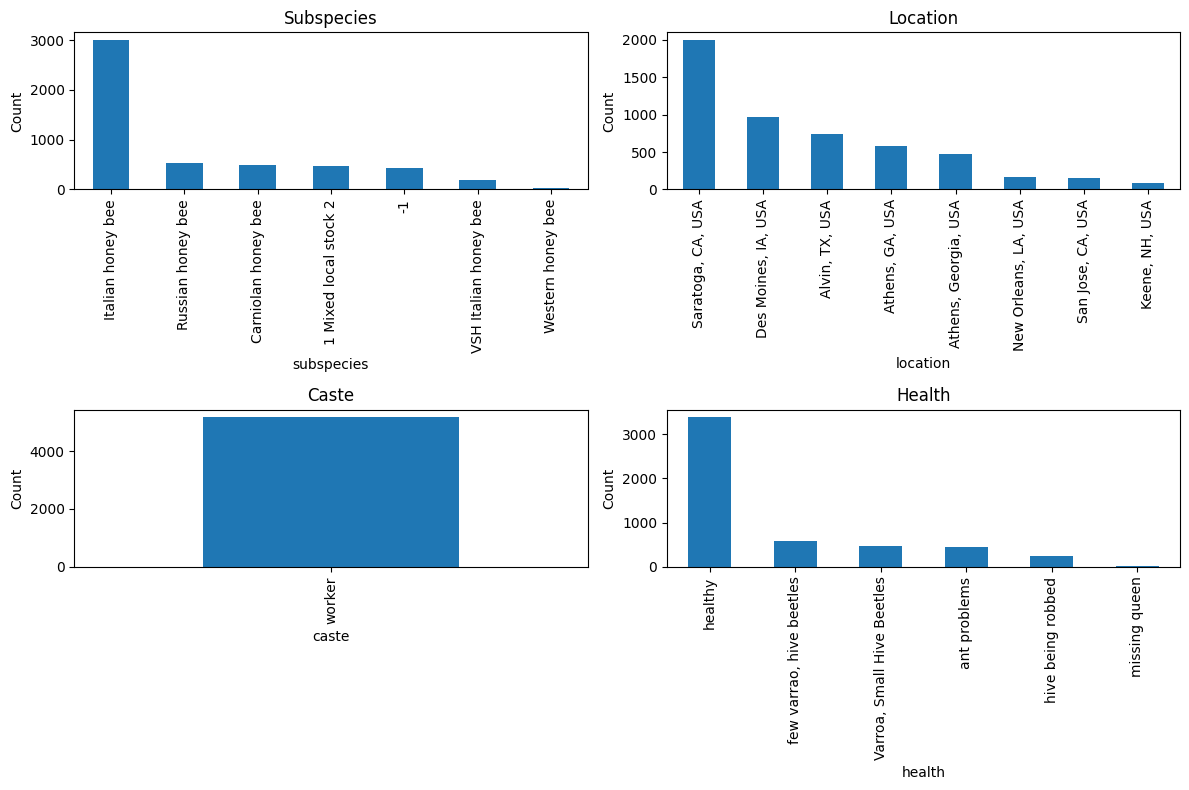

In [ ]:
f, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

bees.subspecies.value_counts().plot(kind='bar',ax=ax[0, 0])
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Subspecies')

bees.location.value_counts().plot(kind='bar', ax=ax[0, 1])
ax[0,1].set_title('Location')
ax[0,1].set_ylabel('Count')

bees.caste.value_counts().plot(kind='bar', ax=ax[1, 0])
ax[1,0].set_title('Caste')
ax[1,0].set_ylabel('Count')

bees.health.value_counts().plot(kind='bar', ax=ax[1,1])
ax[1,1].set_title('Health')
ax[1,1].set_ylabel('Count')

f.subplots_adjust(hspace=0.7)
f.tight_layout()
plt.show()

## 3.2 Look at Bees images

**Subspecies of Bee**

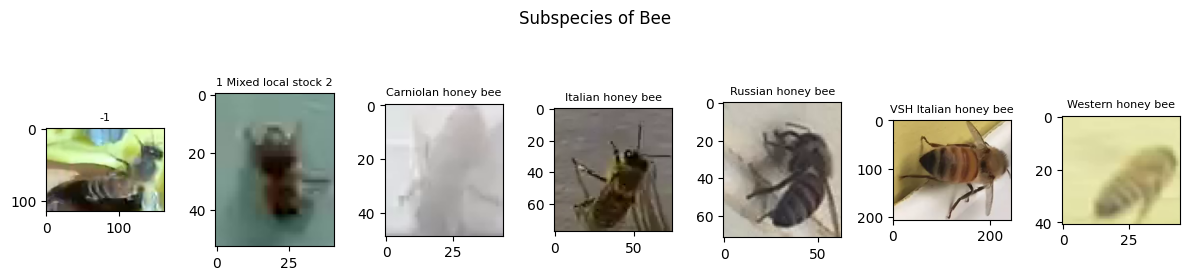

In [ ]:
 # Updated import to avoid future deprecation issues

# Select first X subspecies titles
subspecies = bees['subspecies'].cat.categories
f, ax = plt.subplots(nrows=1, ncols=subspecies.size, figsize=(12, 3))
i = 0

# Draw the first found bee of given subspecies
for s in subspecies:
    if s == 'healthy': continue
    file = img_folder + bees[bees['subspecies'] == s].iloc[0]['file']
    im = imageio.imread(file)
    ax[i].imshow(im, resample=True)
    ax[i].set_title(s, fontsize=8)
    i += 1

plt.suptitle("Subspecies of Bee")
plt.tight_layout()
plt.show()


**Healthy Bees**

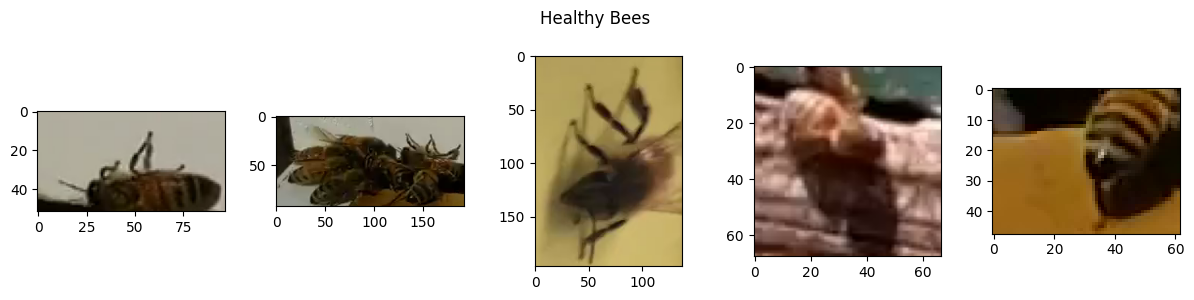

In [ ]:
ncols = 5
healthy = bees[bees['health'] == 'healthy'].sample(ncols)

f, ax = plt.subplots(nrows=1,ncols=ncols, figsize=(12,3))
# Read image of original size from disk, because bees['img'] contains resized numpy array
for i in range(0,5):
    file = img_folder + healthy.iloc[i]['file']
    ax[i].imshow(imageio.imread(file))

plt.suptitle("Healthy Bees")
plt.tight_layout()
plt.show()

**Sick Bees**

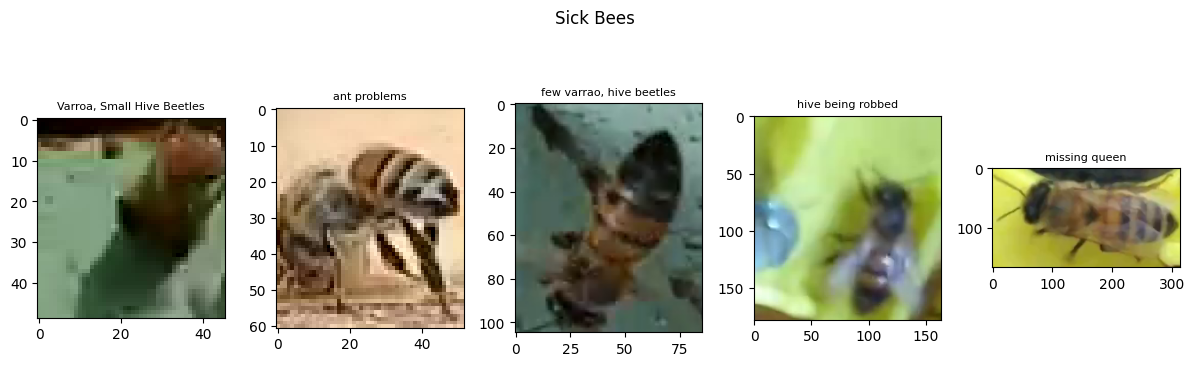

In [ ]:
health_cats = bees['health'].cat.categories
f, ax = plt.subplots(1, health_cats.size-1, figsize=(12,4))
i=0
for c in health_cats:
    if c == 'healthy': continue
    bee = bees[bees['health'] == c].sample(1).iloc[0]
    ax[i].imshow(imageio.imread(img_folder + bee['file']))
    ax[i].set_title(bee['health'], fontsize=8)
    i += 1

plt.suptitle("Sick Bees")
plt.tight_layout()
plt.show()

# 4. Bee subspecies classification
Preprocessing includes data balancing and augmentation.
Then we'll be ready to train CNN.

## 4.1. Data preprocessing for Bee subspecies
### 4.1.1 Balancing samples by subspecies
Split all Bees to train, validation and test. Then balance train dataset.
Splitting should be done before balancing to avoid putting the same upsampled Bee to both train and test.


<ipython-input-10-9fe8fee3fdac>:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_bees_bal = train_bees.groupby(field_name, as_index=False, observed=True).apply(


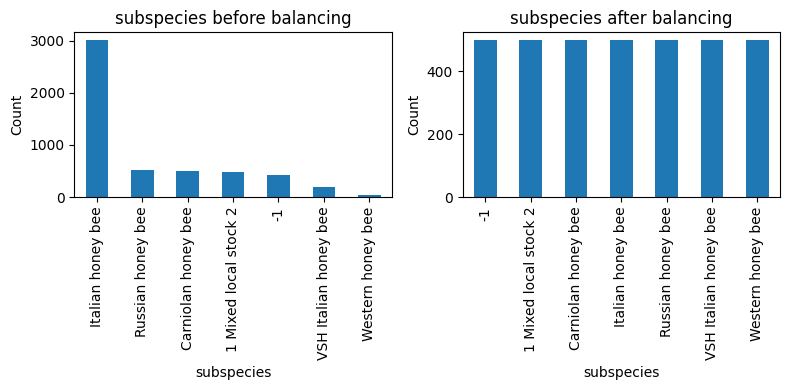

In [ ]:
def split_balance(bees, field_name):
    # Split to train and test before balancing
    train_bees, test_bees = train_test_split(bees, random_state=24)

    # Split train into train and validation datasets
    train_bees, val_bees = train_test_split(train_bees, test_size=0.1, random_state=24)

    # Balance by subspecies for the train dataset
    ncat_bal = int(len(train_bees) / train_bees[field_name].cat.categories.size)

    # Use `include_groups=False` to avoid the deprecated warning
    train_bees_bal = train_bees.groupby(field_name, as_index=False, observed=True).apply(
        lambda g: g.sample(ncat_bal, replace=True, random_state=24)  # Adding random_state for reproducibility
    ).reset_index(drop=True)

    return train_bees_bal, val_bees, test_bees

def plot_balanced(train_bees, train_bees_bal, field_name):
    # Plot before and after balancing
    f, axs = plt.subplots(1, 2, figsize=(8, 4))

    # Before balancing
    ax = train_bees[field_name].value_counts().plot(kind='bar', ax=axs[0])
    ax.set_title(f'{field_name} before balancing')
    ax.set_ylabel('Count')

    # After balancing
    ax = train_bees_bal[field_name].value_counts().plot(kind='bar', ax=axs[1])
    ax.set_title(f'{field_name} after balancing')
    ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

# Split/balance and plot the result
train_bees_bal, val_bees, test_bees = split_balance(bees, 'subspecies')
plot_balanced(bees, train_bees_bal, 'subspecies')

# Use the balanced dataset as main
train_bees = train_bees_bal



### 4.1.2 Prepare features
We prepared train_bees dataset but did not load images from files until this state. Now load them and use ImageDataGenerator to randomly shift/rotate/zoom.

In [ ]:
# The same way of loading images and one hot encoding will be used in 2 places: subspecies and health CNN.
# Let's put this logic in function here to reuse.
def prepare2train(train_bees, val_bees, test_bees, field_name):
    """
    Load images for features, drop other columns
    One hot encode for label, drop other columns
    @return: image generator, train images, validation images, test images, train labels, validation labels, test labels
    """
    # Bees already splitted to train, validation and test
    # Load and transform images to have equal width/height/channels.
    # read_img function is defined in the beginning to use in both health and subspecies.
    # Use np.stack to get NumPy array for CNN input

    # Train data
    train_X = np.stack(train_bees['file'].apply(read_img))
    #train_y = to_categorical(train_bees[field_name].values)
    train_y  = pd.get_dummies(train_bees[field_name], drop_first=False)

    # Validation during training data to calc val_loss metric
    val_X = np.stack(val_bees['file'].apply(read_img))
    #val_y = to_categorical(val_bees[field_name].values)
    val_y = pd.get_dummies(val_bees[field_name], drop_first=False)

    # Test data
    test_X = np.stack(test_bees['file'].apply(read_img))
    #test_y = to_categorical(test_bees[field_name].values)
    test_y = pd.get_dummies(test_bees[field_name], drop_first=False)

    # Data augmentation - a little bit rotate, zoom and shift input images.
    generator = ImageDataGenerator(
            featurewise_center=False,  # set input mean to 0 over the dataset
            samplewise_center=False,  # set each sample mean to 0
            featurewise_std_normalization=False,  # divide inputs by std of the dataset
            samplewise_std_normalization=False,  # divide each input by its std
            zca_whitening=False,  # apply ZCA whitening
            rotation_range=180,  # randomly rotate images in the range (degrees, 0 to 180)
            zoom_range = 0.1, # Randomly zoom image
            width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
            height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
            horizontal_flip=True,  # randomly flip images
            vertical_flip=True)
    generator.fit(train_X)
    return (generator, train_X, val_X, test_X, train_y, val_y, test_y)

#train_bees['subspecies'].cat.values[:-100]
# Call image preparation and one hot encoding
generator, train_X, val_X, test_X, train_y, val_y, test_y = prepare2train(train_bees, val_bees, test_bees, 'subspecies')

In [ ]:
checkpointer1 = ModelCheckpoint('best_model1.weights.h5'
                                ,monitor='val_accuracy'
                                ,verbose=1
                                ,save_best_only=True
                                ,save_weights_only=True)

## 4.2 Train Bee Subspecies CNN

In [ ]:
# We'll stop training if no improvement after some epochs
earlystopper1 = EarlyStopping(monitor='loss', patience=10, verbose=1)

# Build CNN model
model1=Sequential()
model1.add(Conv2D(6, kernel_size=3, input_shape=(img_width, img_height,3), activation='relu', padding='same'))
model1.add(MaxPool2D(2))
model1.add(Conv2D(12, kernel_size=3, activation='relu', padding='same'))
model1.add(Flatten())
model1.add(Dense(train_y.columns.size, activation='softmax'))
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
training1 = model1.fit(generator.flow(train_X,train_y, batch_size=60)
                        ,epochs=20
                        ,validation_data=(val_X, val_y)
                        ,steps_per_epoch=50
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.3014 - loss: 1.7585 - val_accuracy: 0.4639 - val_loss: 1.2776
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7346 - loss: 0.9097 - val_accuracy: 0.6263 - val_loss: 0.9097
Epoch 3/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.7035 - loss: 0.7933 - val_accuracy: 0.6778 - val_loss: 0.8937
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7872 - loss: 0.6078 - val_accuracy: 0.7861 - val_loss: 0.7433
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.7791 - loss: 0.6753 - val_accuracy: 0.7887 - val_loss: 0.6988
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8178 - loss: 0.5881 - val_accuracy: 0.7526 - val_loss: 0.7849
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.8399 - loss: 0.5321 - val_accuracy: 0.7139 - val_loss: 0.7005
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8879 - loss: 0.4316 - val_accuracy: 0.7242 - val_loss: 0.7568
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.8683 - loss: 0.4485 - val_accuracy: 0.7680 - val_loss: 0.6036
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8575 - loss: 0.4182 - val_accuracy: 0.7938 - val_loss

## 4.3 Evaluate bee subspecies detection model

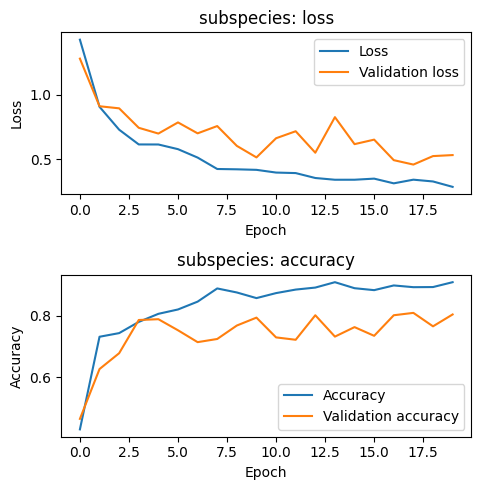

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


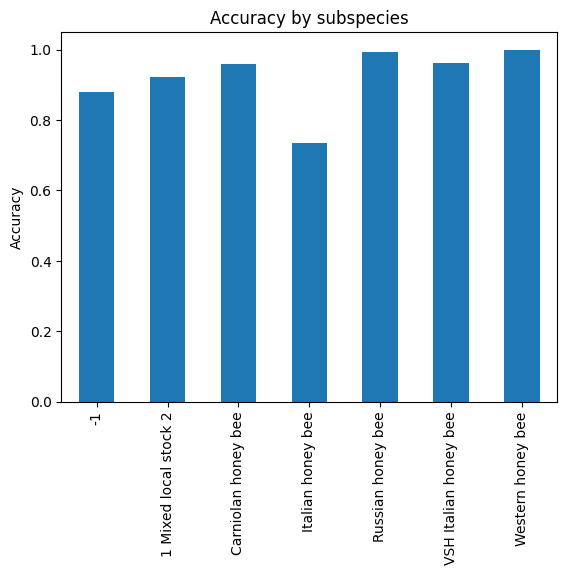

Classification report
                       precision    recall  f1-score   support

                   -1       0.67      0.92      0.77       108
1 Mixed local stock 2       0.44      0.93      0.60       102
  Carniolan honey bee       0.99      0.96      0.97       147
    Italian honey bee       0.99      0.76      0.86       754
    Russian honey bee       0.96      0.99      0.98       124
VSH Italian honey bee       0.74      0.98      0.84        54
    Western honey bee       0.67      1.00      0.80         4

             accuracy                           0.84      1293
            macro avg       0.78      0.93      0.83      1293
         weighted avg       0.90      0.84      0.85      1293

Loss function: 0.4488878846168518, accuracy: 0.8406805992126465


In [ ]:
# This is a function to use in Bee subspecies and health evaluation
def eval_model(training, model, test_X, test_y, field_name):
    """
    Model evaluation: plots, classification report
    @param training: model training history
    @param model: trained model
    @param test_X: features
    @param test_y: labels
    @param field_name: label name to display on plots
    """
    ## Trained model analysis and evaluation
    f, ax = plt.subplots(2,1, figsize=(5,5))
    ax[0].plot(training.history['loss'], label="Loss")
    ax[0].plot(training.history['val_loss'], label="Validation loss")
    ax[0].set_title('%s: loss' % field_name)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    # Accuracy
    ax[1].plot(training1.history['accuracy'], label="Accuracy")
    ax[1].plot(training1.history['val_accuracy'], label="Validation accuracy")
    ax[1].set_title('%s: accuracy' % field_name)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    # Accuracy by subspecies
    test_pred = model.predict(test_X)

    acc_by_subspecies = np.logical_and((test_pred > 0.5), test_y).sum()/test_y.sum()
    acc_by_subspecies.plot(kind='bar', title='Accuracy by %s' % field_name)
    plt.ylabel('Accuracy')
    plt.show()

    # Print metrics
    print("Classification report")
    test_pred = np.argmax(test_pred, axis=1)
    test_truth = np.argmax(test_y.values, axis=1)
    print(metrics.classification_report(test_truth, test_pred, target_names=test_y.columns))

    # Loss function and accuracy
    test_res = model.evaluate(test_X, test_y.values, verbose=0)
    print('Loss function: %s, accuracy:' % test_res[0], test_res[1])

# Call evaluation function
eval_model(training1, model1, test_X, test_y, 'subspecies')

# 5. CNN model for  Bee health classification

## 5.1. Data preprocessing for Bee health classification
### 5.1.1 Balance Bees by health
This balancing 1:1 repeats the one from Bee subspecies section. So just call the function we defined there for reuse.

<ipython-input-10-9fe8fee3fdac>:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_bees_bal = train_bees.groupby(field_name, as_index=False, observed=True).apply(


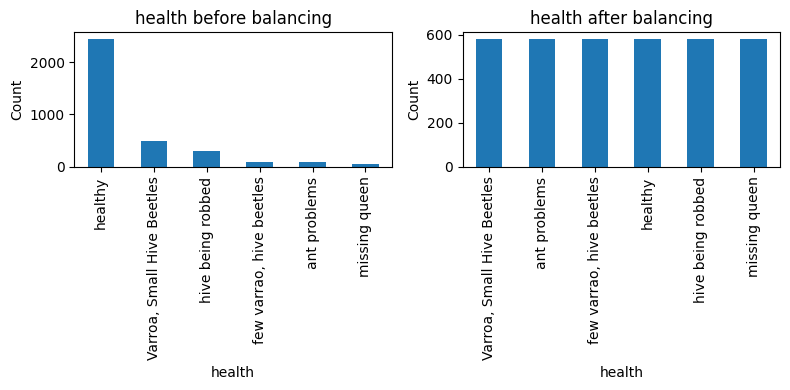

In [ ]:
# Split/balance and plot the result
train_bees_bal, val_bees, test_bees = split_balance(bees, 'health')
plot_balanced(train_bees, train_bees_bal, 'health')

# Will use balanced dataset as main
train_bees_bal = train_bees


### 5.1.2 Features augmentation and labels one hot encoding for Health CNN
The same preparation as in Bee subspecies section, we can again call functions, defined there.


In [ ]:
# Call image preparation and one hot encoding from Bee subspecies section
generator, train_X, val_X, test_X, train_y, val_y, test_y = prepare2train(train_bees, val_bees, test_bees, 'health')

## 5.2 Train Bee health CNN

In [ ]:
# Save the best model during the traning
checkpointer2 = ModelCheckpoint('best_model2.weights.h5'
                                ,monitor='val_acc'
                                ,verbose=1
                                ,save_best_only=True
                                ,save_weights_only=True)

In [ ]:
# We'll stop training if no improvement after some epochs
earlystopper2 = EarlyStopping(monitor='val_acc', patience=10, verbose=1)



# Build CNN model
model2=Sequential()
model2.add(Conv2D(5, kernel_size=3, input_shape=(img_width, img_height,3), activation='relu', padding='same'))
model2.add(MaxPool2D(2))
model2.add(Conv2D(10, kernel_size=3, activation='relu', padding='same'))
model2.add(Flatten())
model2.add(Dense(train_y.columns.size, activation='softmax'))
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
training2 = model2.fit(generator.flow(train_X,train_y, batch_size=50)
                        ,epochs=20
                        ,validation_data=[val_X, val_y]
                        ,steps_per_epoch=50)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.6401 - loss: 1.2208 - val_accuracy: 0.6443 - val_loss: 1.3648
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.7036 - loss: 0.8881 - val_accuracy: 0.6443 - val_loss: 1.2741
Epoch 3/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.7166 - loss: 0.7817 - val_accuracy: 0.6237 - val_loss: 1.1708
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7899 - loss: 0.6308 - val_accuracy: 0.6443 - val_loss: 0.9951
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.8222 - loss: 0.5682 - val_accuracy: 0.6675 - val_loss: 0.9900
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8294 - loss: 0.5640 - val_accuracy: 0.6881 - val_loss: 0.8411
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8488 - loss: 0.4879 - val_accuracy: 0.6856 - val_loss: 0.8674
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8651 - loss: 0.4313 - val_accuracy: 0.7036 - val_loss: 0.7864
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.8679 - loss: 0.4153 - val_accuracy: 0.6907 - val_loss: 0.8036
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8494 - loss: 0.4404 - val_accuracy: 0.7371 - val_l

## 5.3 Evaluate Bee health classification model

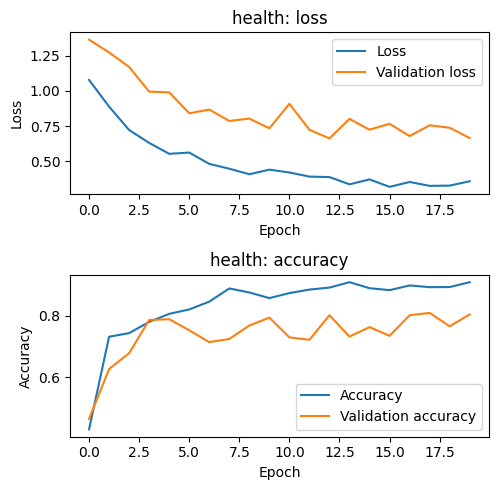

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


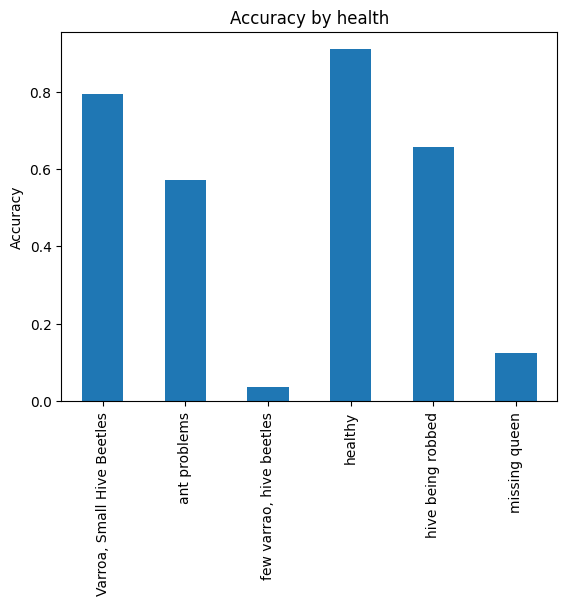

Classification report
                            precision    recall  f1-score   support

Varroa, Small Hive Beetles       0.41      0.83      0.55       102
              ant problems       0.95      0.63      0.76       117
  few varrao, hive beetles       0.70      0.05      0.09       139
                   healthy       0.88      0.94      0.91       866
         hive being robbed       0.55      0.67      0.60        61
             missing queen       0.60      0.38      0.46         8

                  accuracy                           0.79      1293
                 macro avg       0.68      0.58      0.56      1293
              weighted avg       0.82      0.79      0.76      1293

Loss function: 0.5792312622070312, accuracy: 0.7904099225997925


In [ ]:
# Call evaluation with charts, defined in Bee subspecies section
eval_model(training2, model2, test_X, test_y, 'health')

# 6. Visualization of Conv2D layers


Let's look how our models process images. Our models contains Conv2D layers with kernels inside. We are going to convolve a sample image through kernels and see how does it look before and after each kernel. For each kernel visualize: kernel itself, input image, output image. No idea how to interprete these results, let's do it for fun :)

Function for Conv2D layers visualization:

In [ ]:
# Common function for visualization of kernels
def visualize_layer_kernels(img, conv_layer, title):
    """
    Displays how input sample image looks after convolution by each kernel
    :param img: Sample image array
    :param conv_layer: Layer of Conv2D type
    :param title: Text to display on the top
    """
    # Extract kernels from given layer
    weights1 = conv_layer.get_weights()
    kernels = weights1[0]
    kernels_num = kernels.shape[3]

    # Each row contains 3 images: kernel, input image, output image
    f, ax = plt.subplots(kernels_num, 3, figsize=(7, kernels_num*2))

    for i in range(0, kernels_num):
        # Get kernel from the layer and draw it
        kernel=kernels[:,:,:3,i]
        ax[i][0].imshow((kernel * 255).astype(np.uint8), vmin=0, vmax=255)
        ax[i][0].set_title("Kernel %d" % i, fontsize = 9)

        # Get and draw sample image from test data
        ax[i][1].imshow((img * 255).astype(np.uint8), vmin=0, vmax=255)
        ax[i][1].set_title("Before", fontsize=8)

        # Filtered image - apply convolution
        img_filt = scipy.ndimage.filters.convolve(img, kernel)
        ax[i][2].imshow((img_filt * 255).astype(np.uint8), vmin=0, vmax=255)
        ax[i][2].set_title("After", fontsize=8)

    plt.suptitle(title)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

## 6.1 Visualize convolutions in Bee subspecies CNN


<ipython-input-20-211e071c9d3f>:28: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  img_filt = scipy.ndimage.filters.convolve(img, kernel)


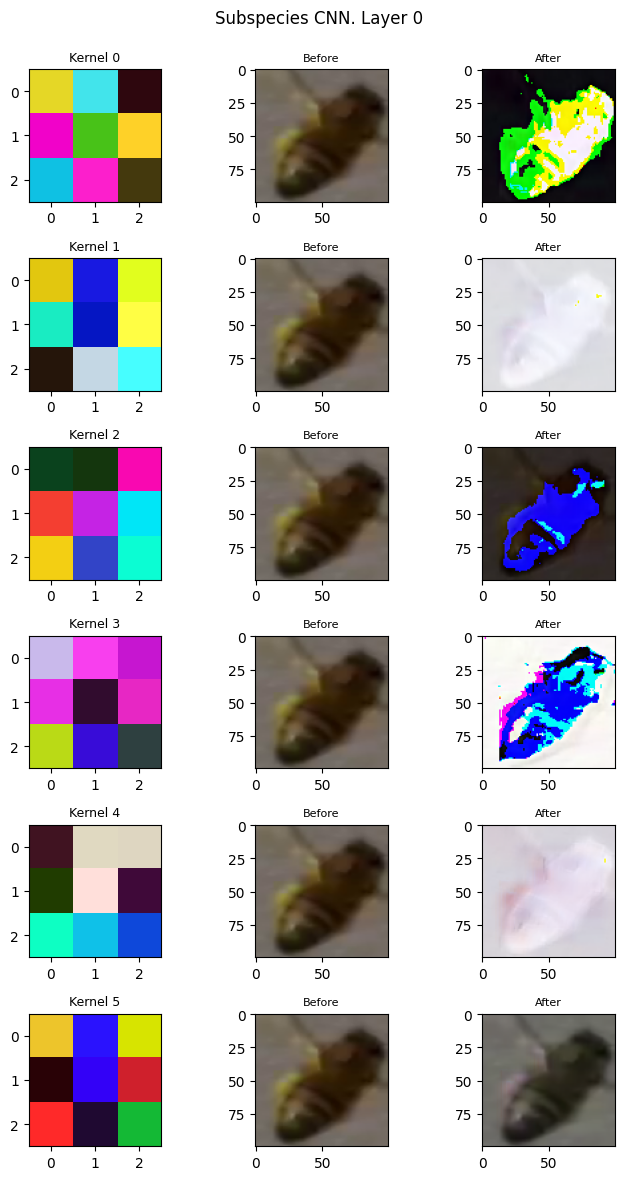

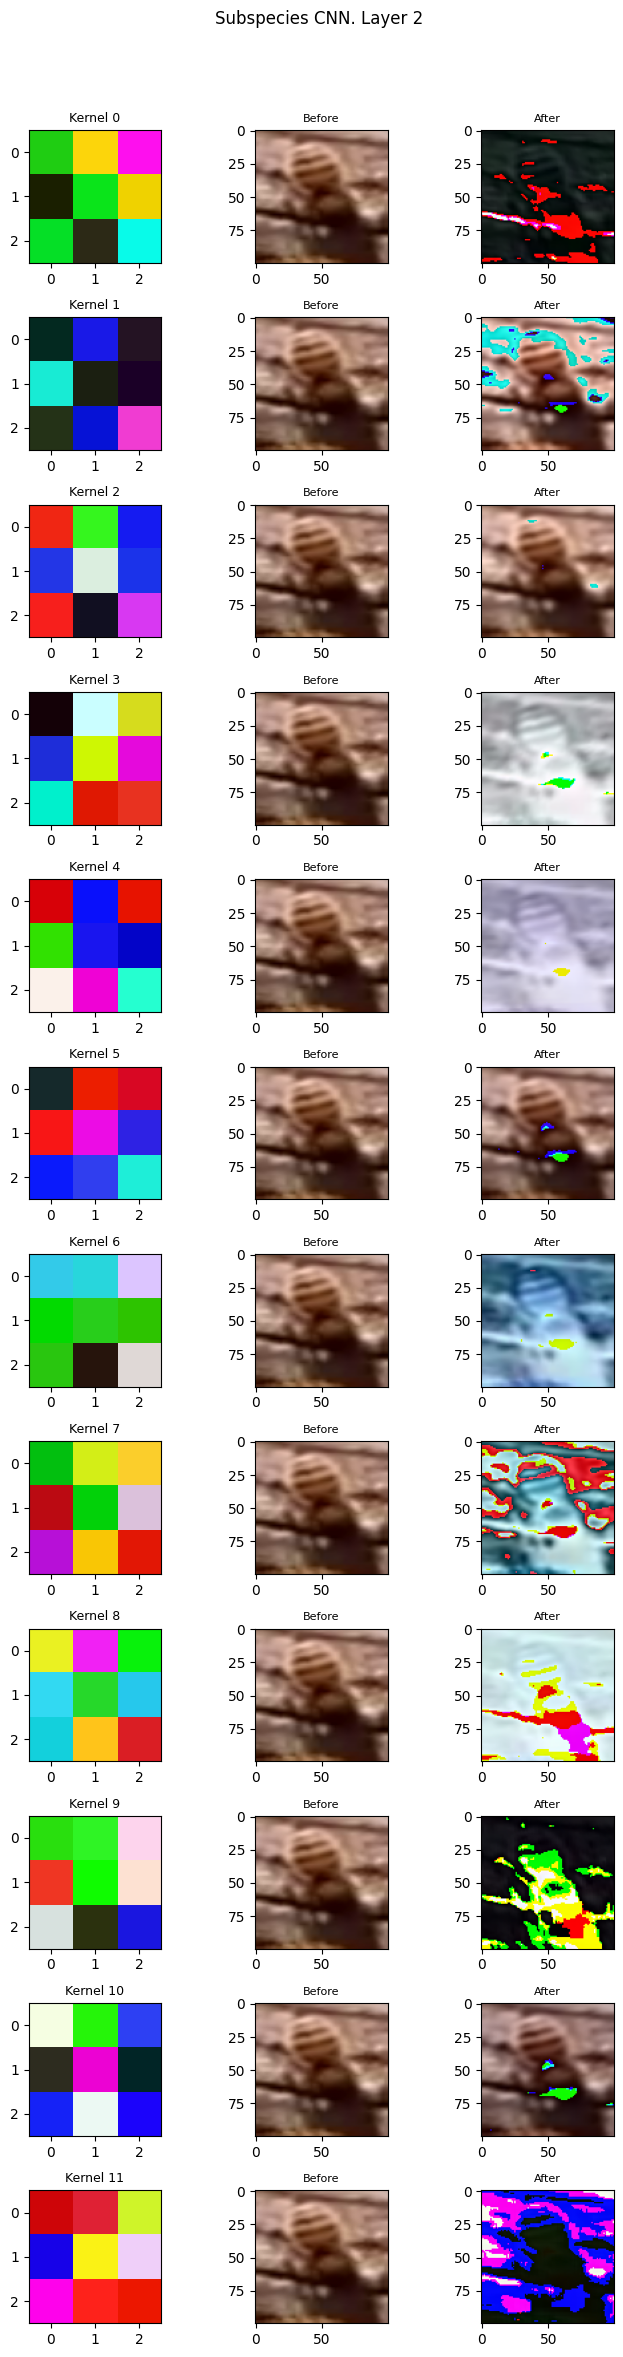

In [ ]:
# Take sample image to visualize convolution
idx = random.randint(0,len(test_X)-1)
img = test_X[idx,:,:,:]
# Take 1st convolutional layer and look at it's filters
conv1 = model1.layers[0]
img = visualize_layer_kernels(img, conv1, "Subspecies CNN. Layer 0")

# Take sample image to visualize convolutoin
idx = random.randint(0,len(test_y)-1)
img = test_X[idx,:,:,:]
# Take another convolutional layer and look at it's filters
conv2 = model1.layers[2]
res = visualize_layer_kernels(img, conv2, "Subspecies CNN. Layer 2")

## 6.2 Visualize convolutions in Bee health CNN

<ipython-input-20-211e071c9d3f>:28: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  img_filt = scipy.ndimage.filters.convolve(img, kernel)


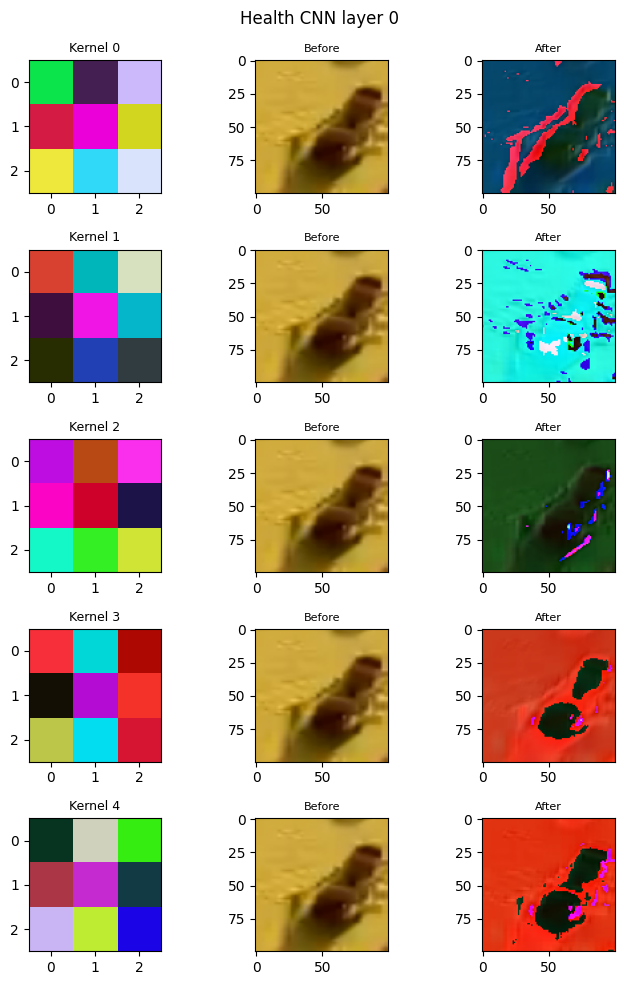

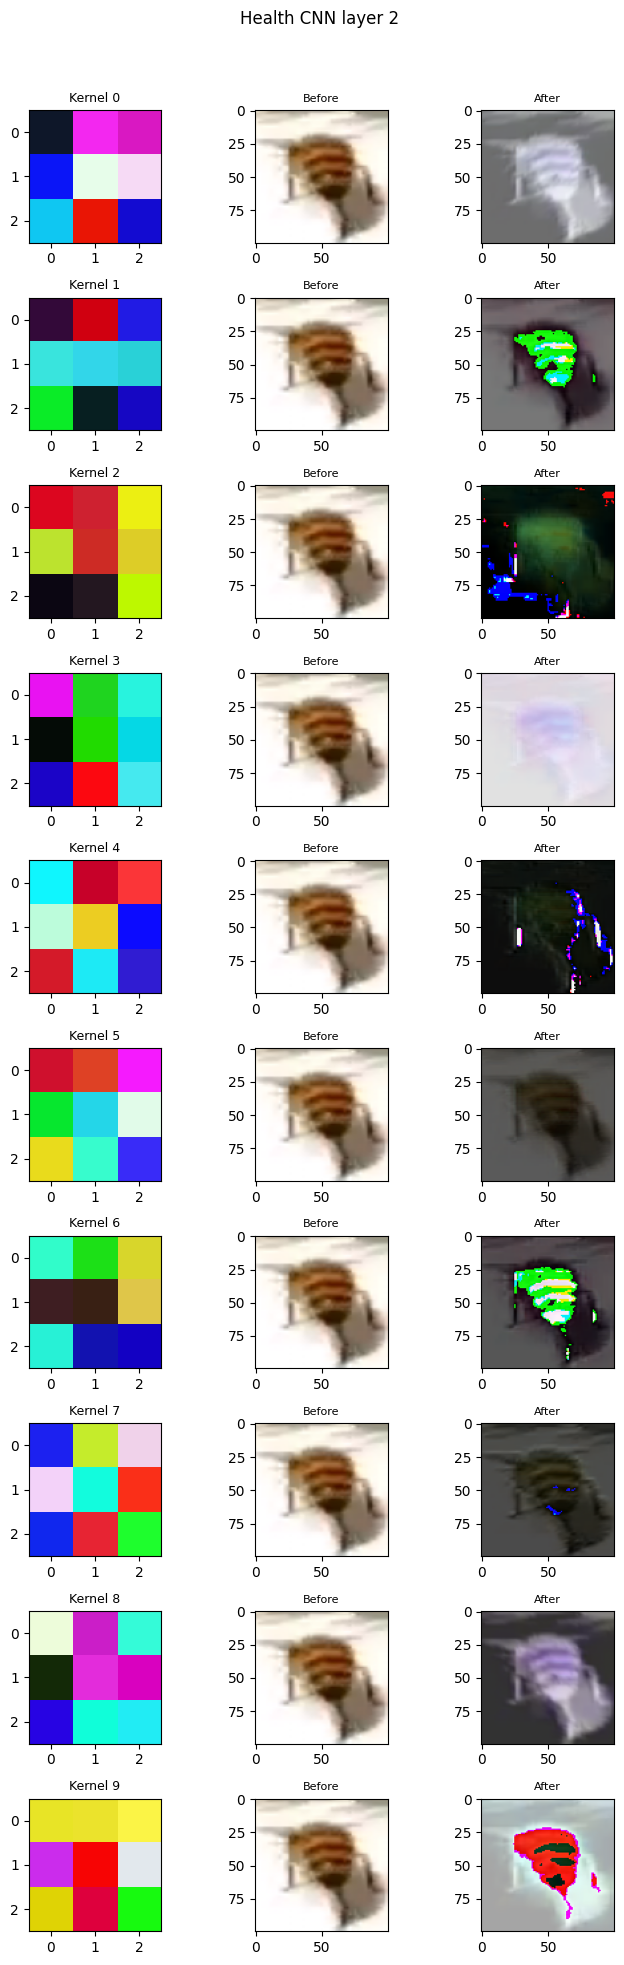

In [ ]:
# Take sample image to visualize convolution
idx = random.randint(0,len(test_X)-1)
img = test_X[idx,:,:,:]
#img = img[:,:,:]
# Take 1st convolutional layer and look at it's filters
conv1 = model2.layers[0]
visualize_layer_kernels(img, conv1, "Health CNN layer 0")

# Take sample image to visualize convolutoin
idx = random.randint(0,len(test_X)-1)
img = test_X[idx,:,:,:]
# Take another convolutional layer and look at it's filters
conv2 = model2.layers[2]
visualize_layer_kernels(img, conv2, "Health CNN layer 2")

In [ ]:
# Get the best saved weights
model1.save('best_model1.weights.h5')

In [ ]:
# Get the best saved weights
model2.save('best_model2.weights.h5')